In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
# from pandas_profiling import ProfileReport

### Загружаем данные

В нашем распоряжении есть три таблички с реальными данными продаж онлайн-магазина, продающего косметику, за 2017 год:
* client_base.csv - информация о клиентах
* item_base.csv - информация о товарах
* order_base.csv - информация о заказах

In [2]:
cl = pd.read_csv('data/client_base.csv', sep=';')
cl.head()

,user_id,order_id,region,city
0,1001351840,1288481004,NaN,Москва
1,1001351840,1290067275,Московская обл.,Москва
2,1001351840,1290133496,Московская обл.,Москва
3,1001377458,1291033504,Ростовская обл.,Ростов-на-Дону
4,1001377458,1291034115,Ростовская обл.,Ростов-на-Дону


In [3]:
item = pd.read_csv('data/item_base.csv', sep=';', decimal=',')
item.head()

,order_id,unit_price,product_discount,total_price,is_sample,art_name,description
0,1289239981,1990,597.0,1393.0,0,S28X4K0000,Губная помада
1,1291239553,1220,0.0,1220.0,0,M1EF020000,Карандаш для бровей
2,1291712092,1390,0.0,1390.0,1,MK88010000,Устойчивый карандаш для губ Pro Longwear Lip P...
3,1292898432,0,0.0,0.0,2,S3FG150000,STUDIO WATERWEIGHT FO-NW
4,1293445922,650,130.0,520.0,0,MCN2010001,Палетка для теней х 4 Pro Palette Eye Shadow


In [4]:
order = pd.read_csv('data/order_base.csv', sep=';', decimal=',')
order.info()

<class 'pandas.DataFrame'>
RangeIndex: 59192 entries, 0 to 59191
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            59192 non-null  int64  
 1   order_date          59192 non-null  str    
 2   fact_delivery_date  30724 non-null  str    
 3   status              59192 non-null  str    
 4   product_price       59192 non-null  str    
 5   delivery_price      59192 non-null  str    
 6   product_discount    59192 non-null  float64
 7   delivery_discount   59192 non-null  str    
 8   total_price         59192 non-null  float64
 9   promocode           54902 non-null  str    
 10  user_id             59192 non-null  int64  
dtypes: float64(2), int64(2), str(7)
memory usage: 11.4 MB


### Приводим столбцы к нужному типу

В каждой из табличек проверяем, что все столбцы имеют тот тип, который мы ожидаем, и в случае, если это не так, приводим к нужному типу.

In [5]:
# таблица с информацией о клиентах
cl.info()

<class 'pandas.DataFrame'>
RangeIndex: 37981 entries, 0 to 37980
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   user_id   37981 non-null  int64
 1   order_id  37981 non-null  int64
 2   region    36858 non-null  str  
 3   city      37981 non-null  str  
dtypes: int64(2), str(2)
memory usage: 2.6 MB


In [6]:
convert_dict = {
    "user_id": str,
    "order_id": str
}
cl = cl.astype(convert_dict)

In [7]:
for column_name in ['region', 'city']:
    cl[column_name] = cl[column_name].str.lower()

In [8]:
cl.info()

<class 'pandas.DataFrame'>
RangeIndex: 37981 entries, 0 to 37980
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   user_id   37981 non-null  str  
 1   order_id  37981 non-null  str  
 2   region    36858 non-null  str  
 3   city      37981 non-null  str  
dtypes: str(4)
memory usage: 3.3 MB


In [9]:
# таблица с информацией о заказах
order.info()

<class 'pandas.DataFrame'>
RangeIndex: 59192 entries, 0 to 59191
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            59192 non-null  int64  
 1   order_date          59192 non-null  str    
 2   fact_delivery_date  30724 non-null  str    
 3   status              59192 non-null  str    
 4   product_price       59192 non-null  str    
 5   delivery_price      59192 non-null  str    
 6   product_discount    59192 non-null  float64
 7   delivery_discount   59192 non-null  str    
 8   total_price         59192 non-null  float64
 9   promocode           54902 non-null  str    
 10  user_id             59192 non-null  int64  
dtypes: float64(2), int64(2), str(7)
memory usage: 11.4 MB


In [10]:
order.fact_delivery_date.unique()

<ArrowStringArray>
[                          nan,                  '18.07.2017',
                  '13.02.2017',                  '06.03.2017',
                  '01.12.2017',                  '21.12.2017',
                  '19.03.2017',                  '12.04.2017',
                  '11.10.2017',                  '26.01.2017',
 ...
 '2017-03-13 16:52:00.0000000', '2017-04-06 11:50:00.0000000',
 '2017-04-10 17:48:13.0000000', '2017-04-04 17:55:00.0000000',
                  '26.01.2018', '2017-02-17 13:26:00.0000000',
 '2017-02-18 15:24:25.0000000', '2017-03-14 17:07:00.0000000',
 '2017-03-02 16:38:11.0000000', '2017-03-06 14:35:00.0000000']
Length: 412, dtype: str

In [11]:
order['order_date'] = pd.to_datetime(order['order_date'])
order['fact_delivery_date'] = pd.to_datetime(order['fact_delivery_date'], dayfirst=True, errors='coerce')

In [12]:
order = order.astype({
    'order_id': str,
    'user_id': str,
    'product_price': float,
    'delivery_price': float,
    'delivery_discount': float
})
order.info()
order.head()

<class 'pandas.DataFrame'>
RangeIndex: 59192 entries, 0 to 59191
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_id            59192 non-null  str           
 1   order_date          59192 non-null  datetime64[us]
 2   fact_delivery_date  30700 non-null  datetime64[us]
 3   status              59192 non-null  str           
 4   product_price       59192 non-null  float64       
 5   delivery_price      59192 non-null  float64       
 6   product_discount    59192 non-null  float64       
 7   delivery_discount   59192 non-null  float64       
 8   total_price         59192 non-null  float64       
 9   promocode           54902 non-null  str           
 10  user_id             59192 non-null  str           
dtypes: datetime64[us](2), float64(5), str(4)
memory usage: 10.5 MB


,order_id,order_date,fact_delivery_date,status,product_price,delivery_price,product_discount,delivery_discount,total_price,promocode,user_id
0,1290295433,2017-11-02,NaT,Заказ отгружен со склада,2.990,0.0,0.0000,0.20,2.9900,"CHECKOUT_SAMPLES_OM,FSS2MINISADD",1007196283
1,1294660083,2017-11-24,NaT,Заказ отгружен со склада,2.691,0.2,0.2990,0.00,2.8910,"CHECKOUT_SAMPLES_OM,WELCOME10",1007412964
2,1293558008,2017-10-10,NaT,Заказ отгружен со склада,4680.000,0.0,0.0000,800.00,4680.0000,"ONEPLUSONE,CHECKOUT_SAMPLES_OM,FSS_4000_RUSSIA...",1006192337
3,1293890649,2017-12-18,NaT,Заказ отгружен со склада,3.171,0.0,0.0981,0.35,3.1719,"CC_INCENTIVE_BENEFITS,CC_INCENTIVE,CHECKOUT_SA...",1007351747
4,1292477242,2017-07-14,2017-07-18,Заказ доставлен покупателю,1300.000,150.0,0.0000,0.00,1450.0000,CHECKOUT_SAMPLES_OM,1007342608


In [13]:
# таблица с информацией о товарах
item.info()

<class 'pandas.DataFrame'>
RangeIndex: 247153 entries, 0 to 247152
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   order_id          247153 non-null  int64  
 1   unit_price        247153 non-null  int64  
 2   product_discount  247153 non-null  float64
 3   total_price       247153 non-null  float64
 4   is_sample         247153 non-null  int64  
 5   art_name          247153 non-null  str    
 6   description       247057 non-null  str    
dtypes: float64(2), int64(3), str(2)
memory usage: 25.8 MB


In [14]:
item = item.astype({'order_id': str, 'is_sample': 'category'})

In [15]:
item.info()

<class 'pandas.DataFrame'>
RangeIndex: 247153 entries, 0 to 247152
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype   
---  ------            --------------   -----   
 0   order_id          247153 non-null  str     
 1   unit_price        247153 non-null  int64   
 2   product_discount  247153 non-null  float64 
 3   total_price       247153 non-null  float64 
 4   is_sample         247153 non-null  category
 5   art_name          247153 non-null  str     
 6   description       247057 non-null  str     
dtypes: category(1), float64(2), int64(1), str(3)
memory usage: 26.5 MB


### Базовая проверка данных

**Основная таблица -- таблица продаж**

In [16]:
order.shape

(59192, 11)

In [17]:
order.select_dtypes(include='object').describe()

C:\Users\alexander\AppData\Local\Temp\ipykernel_12816\1895409568.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  order.select_dtypes(include='object').describe()


,order_id,status,promocode,user_id
count,59192,59192,54902,59192
unique,37843,6,973,24740
top,1295604113,Заказ доставлен покупателю,CHECKOUT_SAMPLES_OM,1007263683
freq,5,30607,5905,143


In [18]:
order.status.unique()

<ArrowStringArray>
[   'Заказ отгружен со склада',  'Заказ доставлен покупателю',
              'Заказ упакован',        'Заказ зарезервирован',
   'Заказ отменен покупателем', 'Заказ возвращен покупателем']
Length: 6, dtype: str

In [19]:
replace_dict = {"Заказ зарезервирован": 1,
                "Заказ упакован": 2,
                "Заказ отгружен со склада": 3,
                "Заказ отменен покупателем": 4,
                "Заказ доставлен покупателю": 5,
                "Заказ возвращен покупателем": 6}

def get_status_int(status):
    return replace_dict[status]

order['status_int'] = order['status'].apply(get_status_int)
order

,order_id,order_date,fact_delivery_date,status,product_price,delivery_price,product_discount,delivery_discount,total_price,promocode,user_id,status_int
0,1290295433,2017-11-02,NaT,Заказ отгружен со склада,2.990,0.0,0.0000,0.20,2.9900,"CHECKOUT_SAMPLES_OM,FSS2MINISADD",1007196283,3
1,1294660083,2017-11-24,NaT,Заказ отгружен со склада,2.691,0.2,0.2990,0.00,2.8910,"CHECKOUT_SAMPLES_OM,WELCOME10",1007412964,3
2,1293558008,2017-10-10,NaT,Заказ отгружен со склада,4680.000,0.0,0.0000,800.00,4680.0000,"ONEPLUSONE,CHECKOUT_SAMPLES_OM,FSS_4000_RUSSIA...",1006192337,3
3,1293890649,2017-12-18,NaT,Заказ отгружен со склада,3.171,0.0,0.0981,0.35,3.1719,"CC_INCENTIVE_BENEFITS,CC_INCENTIVE,CHECKOUT_SA...",1007351747,3
4,1292477242,2017-07-14,2017-07-18,Заказ доставлен покупателю,1300.000,150.0,0.0000,0.00,1450.0000,CHECKOUT_SAMPLES_OM,1007342608,5
...,...,...,...,...,...,...,...,...,...,...,...,...
59187,1294728608,2017-11-26,2017-11-30,Заказ доставлен покупателю,5.040,0.0,0.0000,0.15,5.0400,"FSS_4000_RUSSIA_ONLY,CC_INCENTIVE",1007415452,5
59188,1292850726,2017-03-12,2017-12-23,Заказ доставлен покупателю,4132.000,0.0,127.8000,500.00,4132.2000,"CHECKOUT_SAMPLES_OM,FSS_4000_RUSSIA_ONLY,CC_IN...",1007354330,5
59189,1293895011,2017-11-10,NaT,Заказ отменен покупателем,3.370,0.2,0.0000,0.00,3.5700,NaN,1007375218,4
59190,1294466942,2017-11-24,NaT,Заказ отгружен со склада,4.810,0.0,0.0000,0.80,4.8100,"CC_INCENTIVE,CHECKOUT_SAMPLES_OM,FSS_4000_RUSS...",1007208861,3


In [20]:
order = order.sort_values(['order_id', 'status_int'])
order = order.drop_duplicates(subset='order_id', keep='last')
order.shape

(37843, 12)

In [21]:
order.query('total_price < 0')['status'].unique()
order.total_price = order.total_price.abs()
order.describe()

,order_date,fact_delivery_date,product_price,delivery_price,product_discount,delivery_discount,total_price,status_int
count,37843,30609,37843.000000,37843.000000,37843.000000,37843.000000,37843.000000,37843.000000
mean,2017-07-07 19:14:42.571096,2017-07-04 23:37:02.522787,3619.744078,78.343266,227.884096,218.999631,3698.111762,4.948207
min,2017-01-01 00:00:00,2017-01-09 00:00:00,0.001000,0.000000,0.000000,0.000000,0.001000,3.000000
25%,2017-04-16 00:00:00,2017-03-22 00:00:00,1300.000000,0.000000,0.000000,0.000000,1480.000000,5.000000
50%,2017-07-03 00:00:00,2017-06-27 00:00:00,3250.000000,0.000000,0.000000,200.000000,3470.000000,5.000000
75%,2017-09-28 00:00:00,2017-10-03 00:00:00,4990.000000,150.000000,115.000000,350.000000,4992.000000,5.000000
max,2017-12-31 00:00:00,2018-02-08 00:00:00,40000.000000,800.000000,7182.000000,800.000000,40000.000000,6.000000
std,NaN,NaN,3346.484938,154.736454,520.006408,243.489017,3317.730841,0.436814


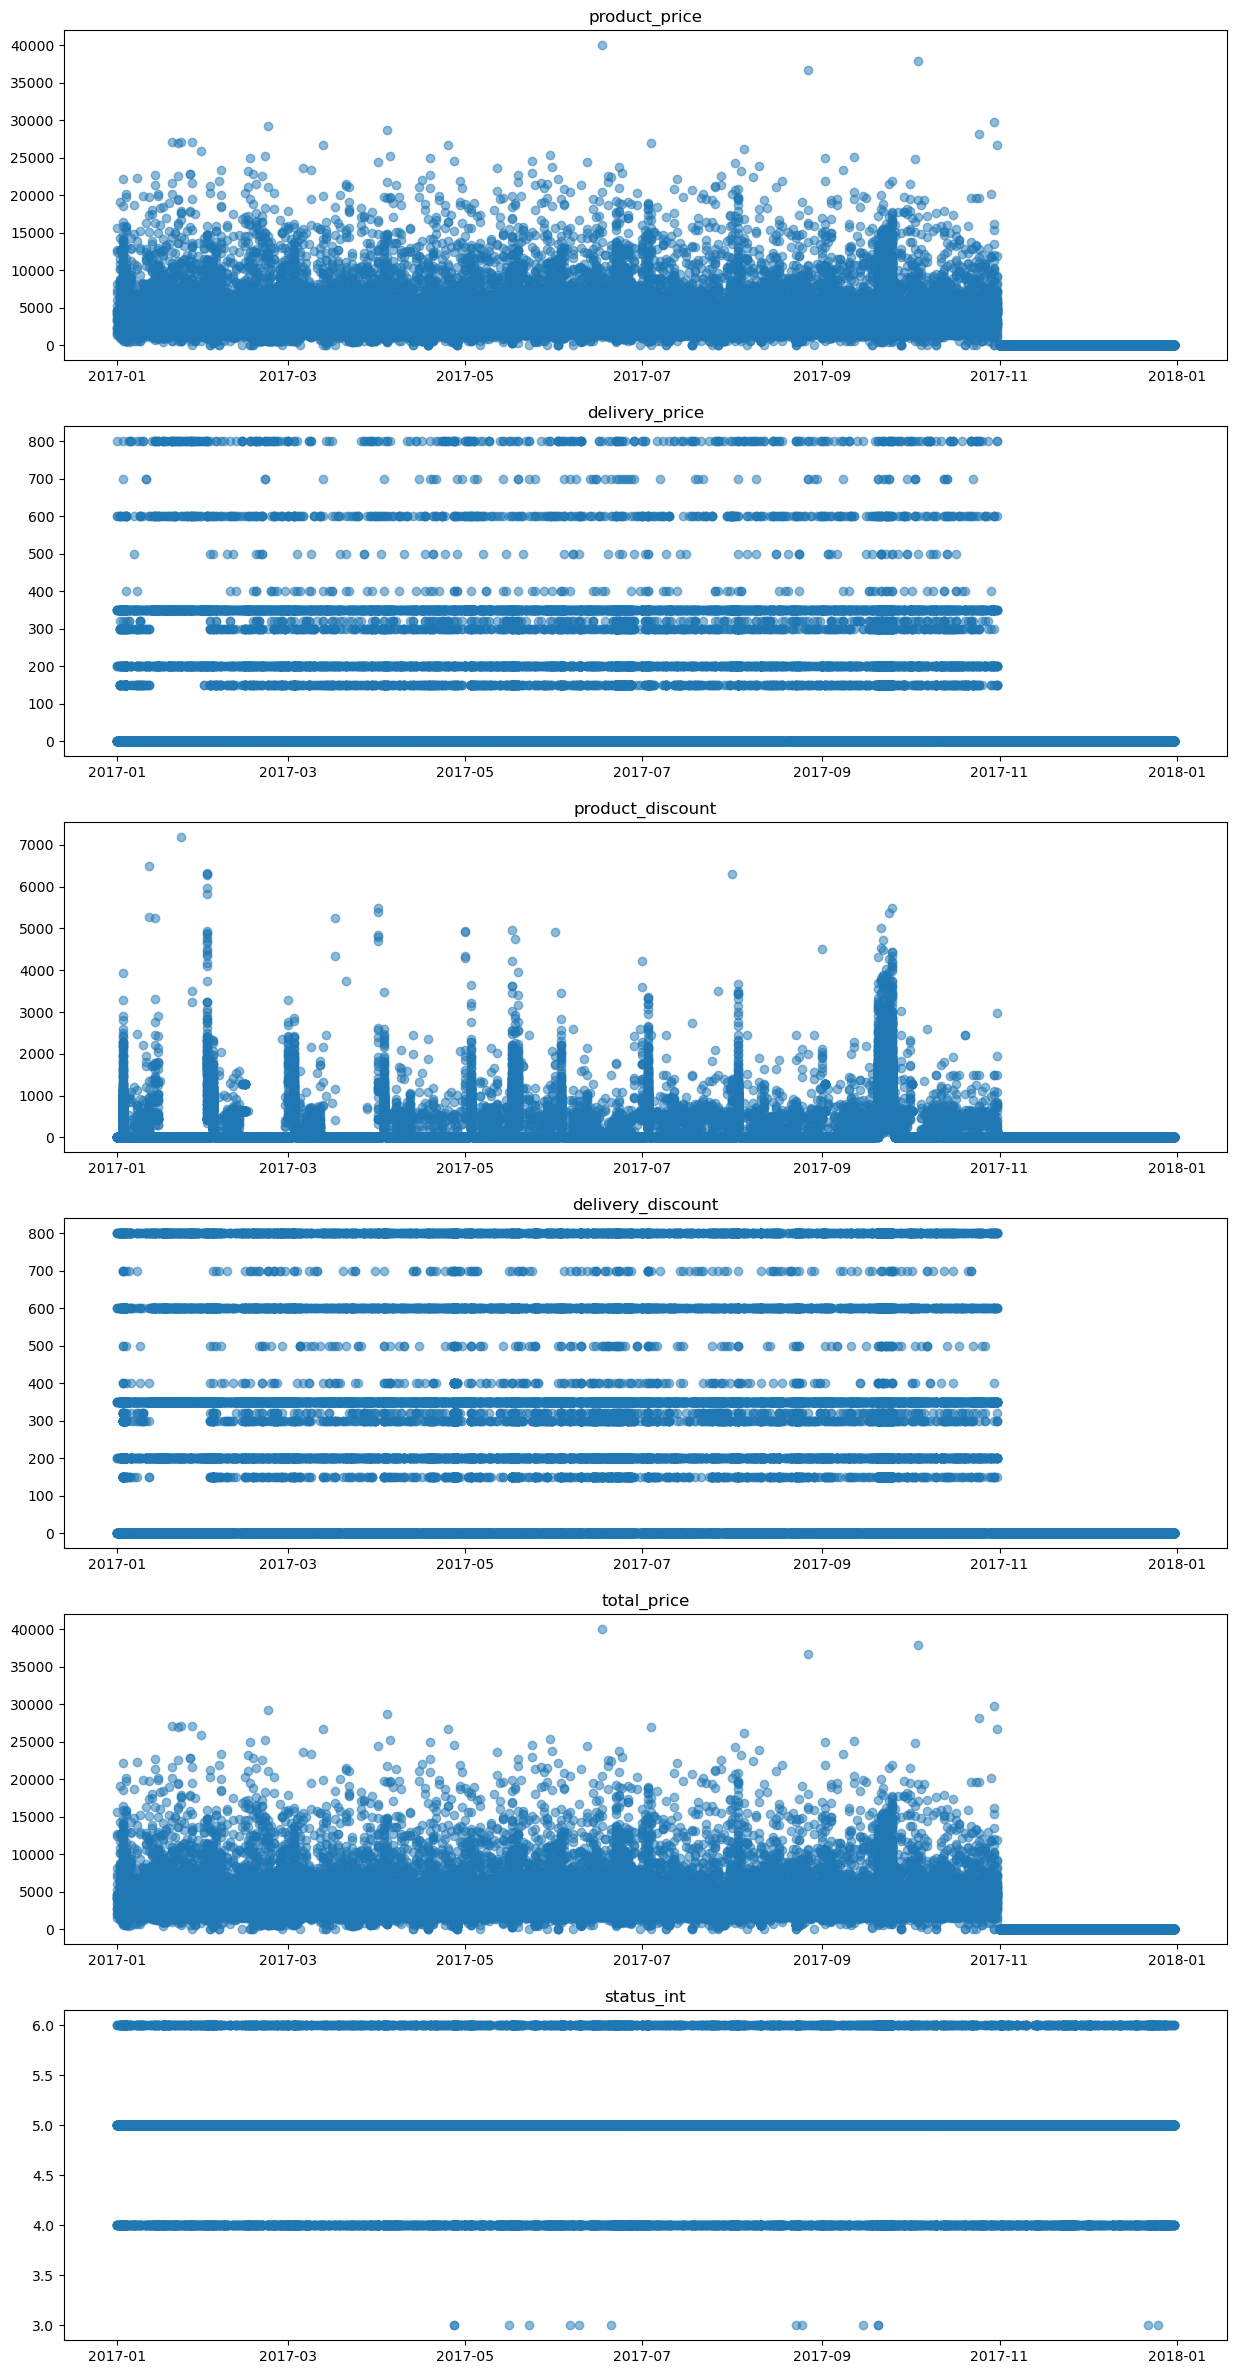

In [22]:
plt.figure(figsize=(15, 30))
df = order.set_index('order_date')
numeric_columns = order.select_dtypes(include=['float', 'int']).columns
for i, column in enumerate(numeric_columns):
    plt.subplot(len(numeric_columns), 1, i+1)
    plt.plot(df[column], 'o', alpha=0.5)
    plt.title(column)

<Axes: >

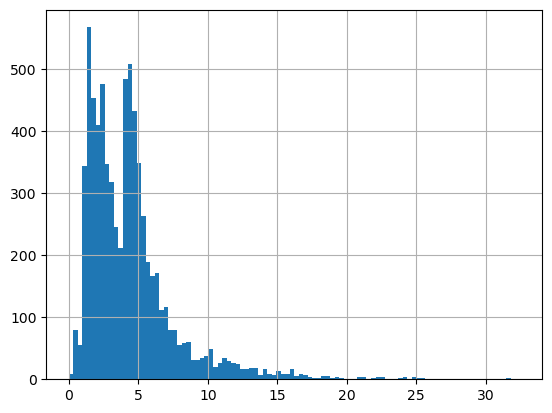

In [23]:
order[order.order_date >= datetime(2017, 11, 1)]['product_price'].hist(bins=100)

In [24]:
def correct_price(row):
    if row.order_date >= datetime(2017, 11, 1):
        for column in ['product_price', 'delivery_price', 'product_discount', 'delivery_discount', 'total_price']:
            row[column] = row[column] * 1000
    return row
    

order = order.apply(correct_price, axis=1)

<Axes: >

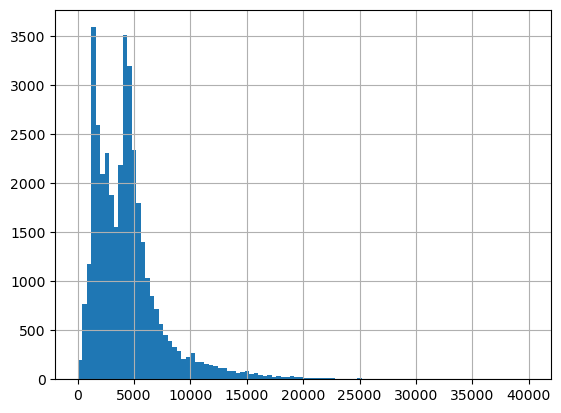

In [25]:
order.product_price.hist(bins=100)

In [26]:
cl.describe()

,user_id,order_id,region,city
count,37981,37981,36858,37981
unique,24740,37843,267,1793
top,1007263683,1293743914,москва,москва
freq,127,2,7422,8789


In [27]:
cl['user_order'] = list(zip(cl.user_id, cl.order_id))
cl.user_order.nunique()

37843

In [28]:
cl[cl.duplicated(subset='user_order', keep=False)]

,user_id,order_id,region,city,user_order
487,1002926020,1293743914,москва,москва,"(1002926020, 1293743914)"
488,1002926020,1293743914,москва г,москва г,"(1002926020, 1293743914)"
1142,1003468141,1293134110,калуга,калуга,"(1003468141, 1293134110)"
1143,1003468141,1293134110,калуга,российская федерация г. калуга,"(1003468141, 1293134110)"
1145,1003468141,1294520899,калужская,калуга,"(1003468141, 1294520899)"
...,...,...,...,...,...
37802,1007437360,1295585197,московская обл.,реутов,"(1007437360, 1295585197)"
37803,1007437365,1295538981,москва,балашиха,"(1007437365, 1295538981)"
37804,1007437365,1295538981,москва,железнодорожный,"(1007437365, 1295538981)"
37883,1007438206,1295522816,сахалинская,южно-сахалинск,"(1007438206, 1295522816)"


In [29]:
cl = cl.drop_duplicates(subset='user_order')
cl.shape

(37843, 5)

In [30]:
cl = cl.drop(columns='user_order')

**Таблица с информацией о клиентах**

In [31]:
item.select_dtypes(include=['object', 'category']).describe() 

C:\Users\alexander\AppData\Local\Temp\ipykernel_12816\183155242.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  item.select_dtypes(include=['object', 'category']).describe()


,order_id,is_sample,art_name,description
count,247153,247153,247153,247057
unique,37843,3,2812,777
top,1290056171,1,S4L3400000,Губная помада Lipstick
freq,28,123539,15862,19852


In [32]:
item.is_sample.value_counts()

is_sample
1    123539
0     93409
2     30205
Name: count, dtype: int64

In [33]:
item.is_sample = item.is_sample.replace(2, 1)

In [34]:
item.describe()

,unit_price,product_discount,total_price
count,247153.000000,247153.000000,247153.000000
mean,1383.820411,78.137792,1365.811162
std,1037.193931,167.017504,1113.251886
min,0.000000,0.000000,0.000000
25%,470.000000,0.000000,470.000000
50%,1480.000000,0.000000,1400.000000
75%,1950.000000,57.900000,1920.000000
max,8300.000000,3499.000000,24600.000000


### Объединяем основную таблицу order и недостающую информацию из двух других таблиц


1. Понять, каким образом мы хотим сделать объединение (left, inner, outer)


2. Выбрать метод, которым мы будем объединять


3. После любого объединения нужно всегда проверять, что количество строк в итоговой таблице ровно такое, как мы ожидаем

In [35]:
order.shape

(37843, 12)

In [36]:
cl.shape

(37843, 4)

In [37]:
data = order.merge(cl, on=['user_id', 'order_id'], how='left')

In [38]:
data.shape

(37843, 14)

In [39]:
item.shape

(247153, 7)

In [40]:
item.sort_values('order_id')

,order_id,unit_price,product_discount,total_price,is_sample,art_name,description
35543,1287755614,1260,163.8,1096.2,0,S4W9950000,Карандаш для губ Lip Pencil
56991,1287755614,1380,179.4,1200.6,0,M2501J0000,Тени для век Eye Shadow
78015,1287755614,1260,163.8,1096.2,1,S4W9950000,Карандаш для губ Lip Pencil
81816,1287755614,1860,241.8,1618.2,1,MTR8010000,Минеральные тени для век
104167,1287755614,1380,179.4,1200.6,1,M2501J0000,Тени для век Eye Shadow
...,...,...,...,...,...,...,...
77817,1295650796,0,0.0,0.0,1,S86H400000,LIPSTICK SAMPLE
80099,1295650796,1015,0.0,1015.0,0,S7K7100000,ГУБНАЯ ПОМАДА
110902,1295650796,1330,0.0,1330.0,0,S28X4N0000,Губная помада
189154,1295650796,2700,0.0,2700.0,0,S77K010000,Перламутровая пудра для лица


In [41]:
item.is_sample = item.is_sample.astype(int)
item_gb = item.groupby('order_id').agg({'art_name': 'count', 'is_sample': 'sum'})
item_gb.columns = ['n_items', 'n_samples']
item_gb = item_gb.reset_index()
item_gb.shape

(37843, 3)

In [42]:
item_gb

,order_id,n_items,n_samples
0,1287755614,6,3
1,1287757139,4,2
2,1287758032,4,3
3,1287766992,10,6
4,1287767076,8,5
...,...,...,...
37838,1295649235,6,3
37839,1295649668,4,3
37840,1295649715,2,1
37841,1295650441,6,4


In [43]:
data = data.merge(item_gb, on='order_id', how='left')

In [44]:
data['is_returned'] = data.status_int == 6

In [45]:
data['use_promocode'] = data.promocode.notnull()
data

,order_id,order_date,fact_delivery_date,status,product_price,delivery_price,product_discount,delivery_discount,total_price,promocode,user_id,status_int,region,city,n_items,n_samples,is_returned,use_promocode
0,1287755614,2017-12-28,2018-01-11,Заказ доставлен покупателю,3915.0,0.0,585.0,500.0,3915.0,"FSS_4000_RUSSIA_ONLY,CC_INCENTIVE_BENEFITS,CC_...",1005835853,5,приморский край,находка,6,3,False,True
1,1287757139,2017-05-25,2017-06-05,Заказ доставлен покупателю,6650.0,0.0,0.0,600.0,6650.0,FSS_4000_RUSSIA_ONLY,1005937384,5,ямало-ненецкий,лабытнанги,4,2,False,True
2,1287758032,2017-04-20,NaT,Заказ отменен покупателем,5040.0,0.0,0.0,200.0,5040.0,"FSS_4000_RUSSIA_ONLY,MACPRO",1005539163,4,москва,москва,4,3,False,True
3,1287766992,2017-11-01,2017-01-16,Заказ доставлен покупателю,9620.0,0.0,0.0,350.0,9620.0,"FSS_3500,CHECKOUT_SAMPLES_OM",1007217042,5,карачаево-черкесская,черкесск,10,6,False,True
4,1287767076,2017-09-01,2017-01-18,Заказ доставлен покупателю,4000.0,0.0,0.0,350.0,4000.0,"FSS_3500,CHECKOUT_SAMPLES_OM",1004155781,5,чеченская,шали,8,5,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37838,1295649235,2017-12-31,2018-01-18,Заказ доставлен покупателю,7390.0,0.0,0.0,350.0,7390.0,FSS_4000_RUSSIA_ONLY,1007439132,5,калужская,обнинск,6,3,False,True
37839,1295649668,2017-12-31,2018-01-07,Заказ доставлен покупателю,2289.0,150.0,0.0,0.0,2439.0,"CHECKOUT_SAMPLES_OM,CC_INCENTIVE",1007439151,5,московская обл.,мытищи,4,3,False,True
37840,1295649715,2017-12-31,2018-01-06,Заказ доставлен покупателю,1036.0,300.0,0.0,0.0,1336.0,CC_INCENTIVE,1007439143,5,нижегородская обл.,нижний новгород,2,1,False,True
37841,1295650441,2017-12-31,2018-01-11,Заказ доставлен покупателю,4228.0,0.0,631.8,350.0,4228.2,"CC_INCENTIVE_BENEFITS,WELCOME10,CHECKOUT_SAMPL...",1007439159,5,волгоградская,волгоград,6,4,False,True


In [46]:
# profile = ProfileReport(data)
# profile

### В поисках факторов, которые влияют на возврат продукта

In [47]:
scale = sum(data["is_returned"] == 1) / sum(data["is_returned"] == 0)

In [60]:
target_columns

['product_price',
 'delivery_price',
 'product_discount',
 'delivery_discount',
 'n_items',
 'n_samples']

In [61]:
numeric_columns

Index(['product_price', 'delivery_price', 'product_discount',
       'delivery_discount', 'total_price', 'status_int'],
      dtype='str')

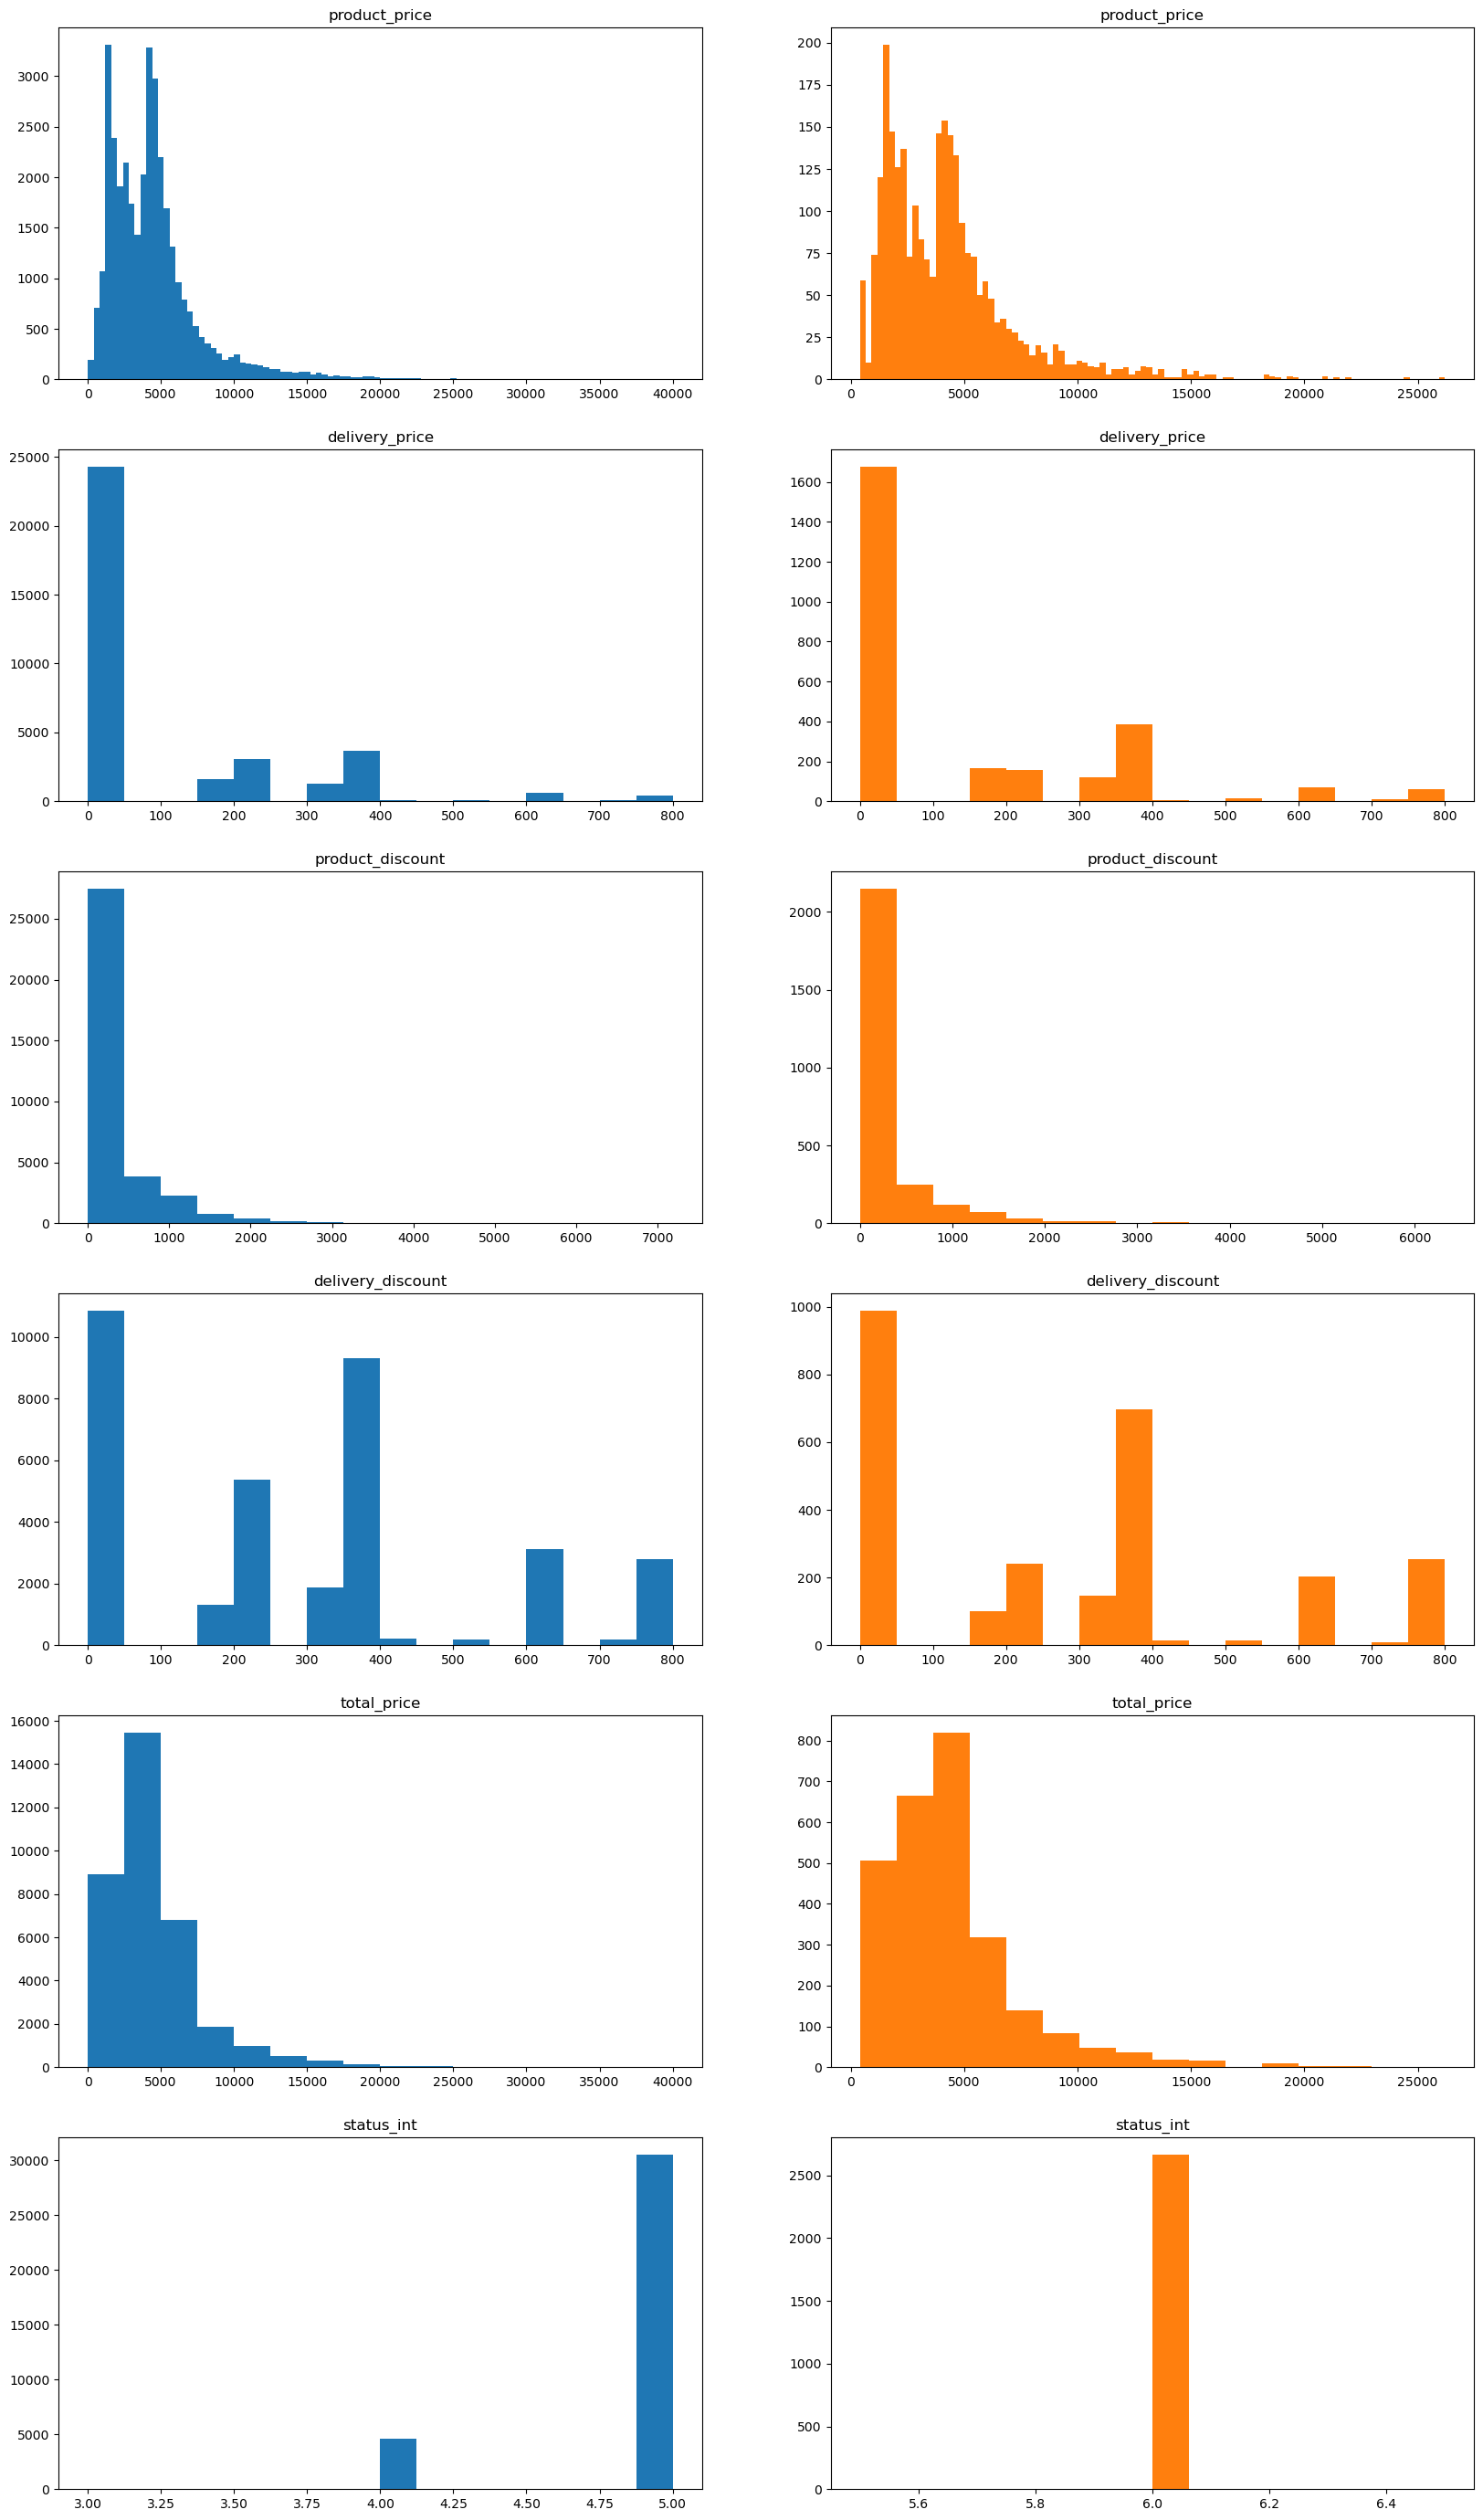

In [65]:
plt.figure(figsize=(20, 35))

target_columns = numeric_columns

k = 1
for colname in target_columns:
    if colname == "product_price":
        bins = 100
    else:
        bins = 16

    plt.subplot(len(target_columns), 2, k)
    plt.hist(data[data["is_returned"] == 0][colname], bins=bins)
    plt.title(colname)

    plt.subplot(len(target_columns), 2, k+1)
    plt.hist(data[data["is_returned"] == 1][colname], color="tab:orange", bins=bins)
    plt.title(colname)

    k+=2